In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
dataset = pd.read_csv("../data/creditcard.csv")
print("==========================================")
print(f"Row: {len(dataset)}")
print(f"Columns: {dataset.columns.__len__()}")
print(dataset.head(5))

Row: 284807
Columns: 31
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        

In [71]:
# Dataset Info
print("=== DataSet Info ===")
print(f"Row: {len(dataset)}")
print(f"Columns: {dataset.columns.to_list()}")
print(f"\n Missing values: \n {dataset.isnull().sum()}")

=== DataSet Info ===
Row: 284807
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

 Missing values: 
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [72]:
print(dataset['Class'].value_counts())
print(dataset['Class'].value_counts(normalize=True)*100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


- This dataset contains credit card transactions with highly imbalanced classes where fraudulent transactions are very rare (~0.17%). The features V1–V28 are PCA-transformed and anonymized. The task is a supervised classification problem where we train a model to detect fraud. Since the dataset is imbalanced, accuracy is not a reliable metric, so we focus on recall and precision.
- I have labeled historical transaction data. I will train a supervised machine learning model to learn patterns of fraudulent transactions and predict fraud on unseen future data.

In [73]:
fraud = dataset[dataset['Class'] ==1]
non_fraud = dataset[dataset['Class'] ==0]
print("=========fraud Amount =========")
print(fraud['Amount'].describe())
print("=======Non-Fraud Amount=====")
print(non_fraud['Amount'].describe())


=========fraud Amount =========
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64
=======Non-Fraud Amount=====
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


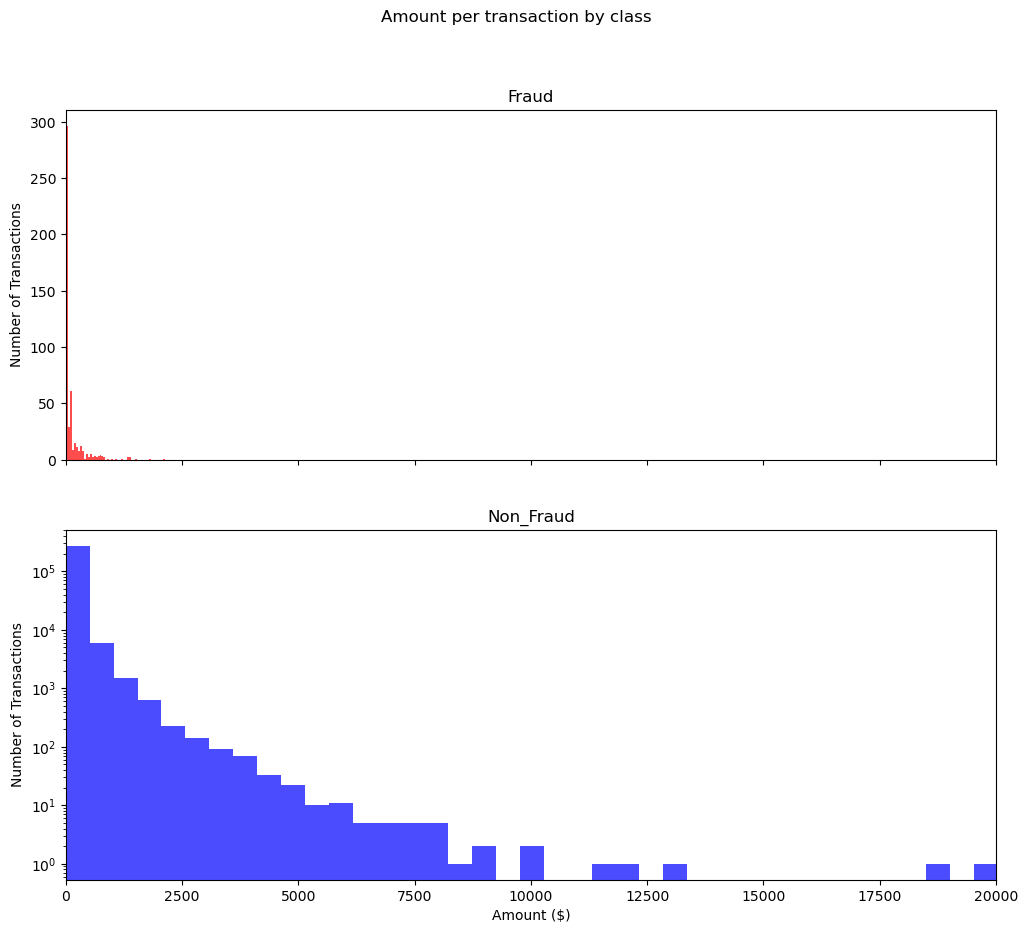

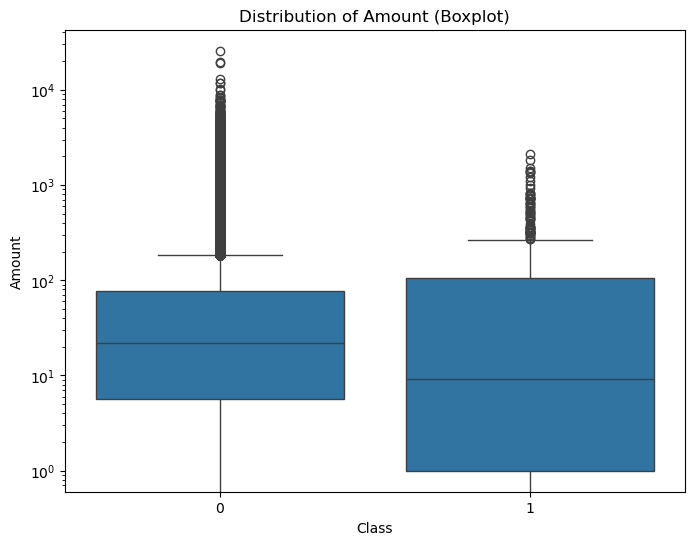

In [74]:

# Set up a figure with two subplots (one for Fraud, one for Normal)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Amount per transaction by class')

# Plot for Fraudulent Transactions
ax1.hist(dataset[dataset['Class'] == 1].Amount, bins=50, color='red', alpha=0.7)
ax1.set_title('Fraud')
ax1.set_ylabel('Number of Transactions')

# Plot for Non-Fraudulent Transactions
ax2.hist(dataset[dataset['Class'] == 0].Amount, bins=50, color='blue', alpha=0.7)
ax2.set_title('Non_Fraud')
ax2.set_ylabel('Number of Transactions')

plt.xlabel('Amount ($)')
plt.xlim((0, 20000)) 
plt.yscale('log')   
plt.show()

# The Boxplot (Great for seeing outliers)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Class', y='Amount', data=dataset)
plt.title('Distribution of Amount (Boxplot)')
plt.yscale('log') # Scaling helps because amounts vary wildly
plt.show()

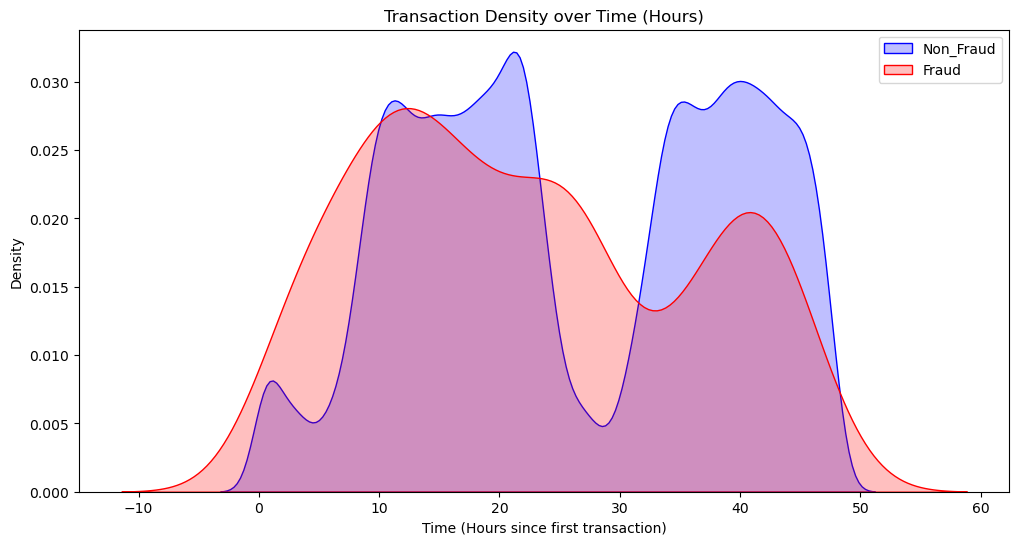

In [75]:
# Analyisng the Time attritubes to get the information of the fraud and non fraud transcations
dataset['Hours'] = dataset['Time']/3600

fraud = dataset[dataset['Class']==1]
non_fraud = dataset[dataset['Class']==0]

plt.figure(figsize=(12,6))

sns.kdeplot(non_fraud['Hours'], color='blue', label='Non_Fraud', fill=True)
sns.kdeplot(fraud['Hours'], color='red', label='Fraud', fill=True)

plt.title("Transaction Density over Time (Hours)")
plt.xlabel("Time (Hours since first transaction)")
plt.ylabel("Density")
plt.legend()
plt.show()


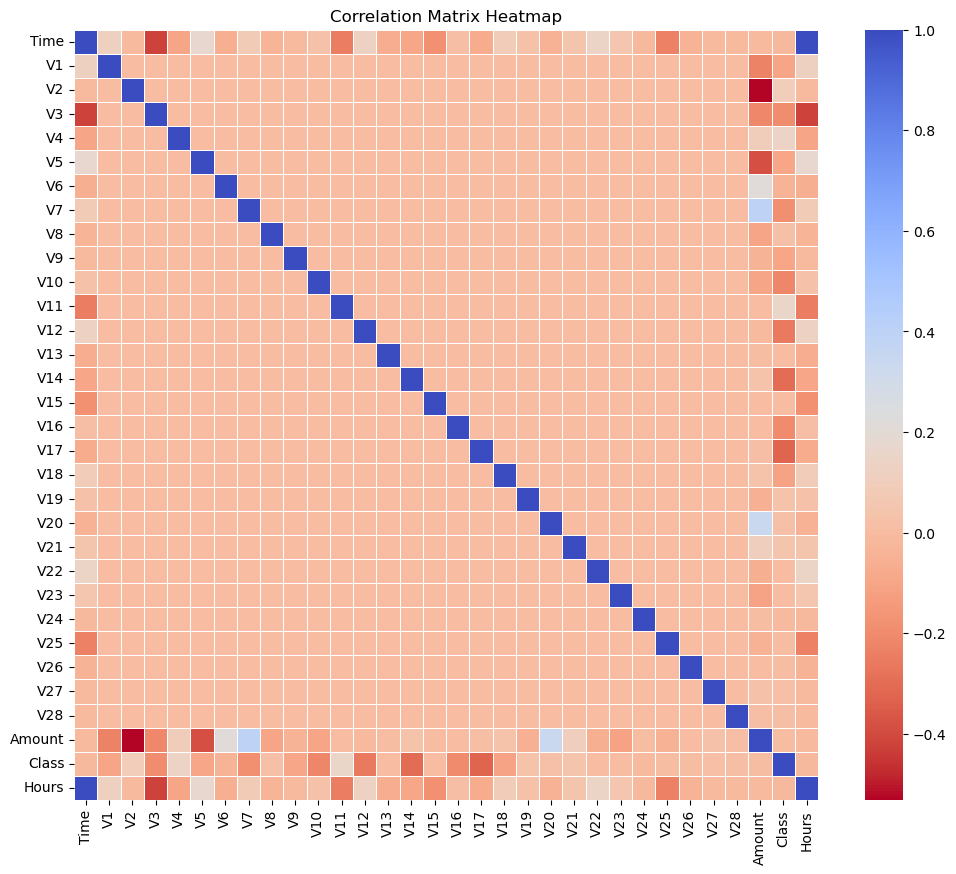

In [76]:
corr = dataset.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm_r', annot=False, linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()